In [1]:
from sklearn.feature_extraction.text import CountVectorizer
from pyLDAvis import gensim_models as gensimvis
from gensim.models import CoherenceModel
from nltk.tokenize import word_tokenize
from nltk.stem import WordNetLemmatizer
from gensim.corpora import Dictionary
from wordsegment import load, segment
from gensim.models import LdaModel
from nltk.corpus import stopwords
from nltk.corpus import wordnet
from wordcloud import WordCloud
import matplotlib.pyplot as plt
from pyLDAvis import save_html
from pprint import pprint
from nltk import pos_tag
import pandas as pd
import pyLDAvis
import nltk
import re
import os

In [2]:
load()  
nltk.download('punkt')
nltk.download('wordnet')
nltk.download('stopwords')
nltk.download('averaged_perceptron_tagger_eng')

[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\Edoardo\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\Edoardo\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\Edoardo\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package averaged_perceptron_tagger_eng to
[nltk_data]     C:\Users\Edoardo\AppData\Roaming\nltk_data...
[nltk_data]   Package averaged_perceptron_tagger_eng is already up-to-
[nltk_data]       date!


True

# <b> 0. Text Pre-processing

In [3]:
def wn_tag(ptag):
    """
    Convert NLTK POS tags to WordNet POS tags.
    """
    if ptag.startswith('J'): return wordnet.ADJ
    if ptag.startswith('V'): return wordnet.VERB
    if ptag.startswith('N'): return wordnet.NOUN
    if ptag.startswith('R'): return wordnet.ADV
    return wordnet.NOUN

In [4]:
def segment_tokenize_text(text):
    """
    Segments the input tokens into words using wordsegment, then returns the list of tokens.
    """
    stops = stopwords.words('english')
            
    tokens = word_tokenize(text)

    token_list = []
    for token in tokens:
        if token.isalpha() and token not in stops:
            seg = segment(token)
            token_list.extend(seg)

    return token_list

In [5]:
def preprocess_text(text):
    """
    Preprocess the input text by removing unwanted characters and normalizing it.
    """
    pattern = r'[^A-Za-z\s]'
    text = re.sub(pattern, '', text)
    text = text.lower()
    text = re.sub(r'\s+', ' ', text)
    text = text.strip()

    token_list = segment_tokenize_text(text)

    return token_list

In [6]:
def load_file_content(file_path):
    """
    Loads the content of a file.
    """
    with open(file_path, 'r', encoding='utf-8') as f:
        corpus = f.read()
    
    return corpus

In [7]:
def get_status_date(file_dir):
    """
    Extracts the status and date from the file name.
    """
    pattern = re.compile(
    r'_H.R.\d{1,4}_(?P<status>.+?) \((?P<date>\d{2}_\d{2}_\d{4})\)\.txt$'
    )

    m = pattern.search(file_dir)
    if m:
        return m.group('status').strip(), m.group('date').strip()

In [8]:
def lemmatize(pos_tags):
    """
    Lemmatize the input tokens using WordNetLemmatizer."""
    stops = set(stopwords.words('english'))
    lemmatizer = WordNetLemmatizer()
    lemmas = []
    for token, ptag in pos_tags:
        wn_ptag = wn_tag(ptag)
        lemmas.append(lemmatizer.lemmatize(token, wn_ptag))

    tokens = [l for l in lemmas if l not in stops and len(l) > 2]
    return tokens

In [9]:
folder_path = 'summaries118'
data = []

In [10]:
for idx, file_dir in enumerate(os.scandir(folder_path)):
    file_path = os.path.join(folder_path, file_dir.name)
    
    status,date = get_status_date(file_dir.name)
    corpus = load_file_content(file_path)

    tokens = preprocess_text(corpus)

    n_rec = {
        'id': idx,
        'content':corpus,
        'tokens': tokens,
        'file_name': file_dir,
        'status': status,
        'date': date.replace('_', '-')
    }

    data.append(n_rec)

In [11]:
df = pd.DataFrame(data)

In [12]:
df['pos_tags'] = df['tokens'].map(lambda x: pos_tag(x))

In [13]:
df['lemmatized_tokens'] = df['pos_tags'].map(lambda x: lemmatize(x))

# <b>1. Topic Modeling

## ***A - LDA***

In [14]:
# 0.25 --> 3748, 0.50 --> 3762, 0.75 --> 3762, 0.90 --> 3763
tokens = df['lemmatized_tokens'].tolist()
dictionary = Dictionary(tokens)
dictionary.filter_extremes(no_below=5, no_above=0.5)
print(f"Dictionary size: {len(dictionary)}")

Dictionary size: 3762


In [15]:
corpus = [dictionary.doc2bow(token) for token in tokens]
for i in range(5):
    print(f'Doc-{i}',corpus[i])

Doc-0 [(0, 1), (1, 1), (2, 2), (3, 1), (4, 1), (5, 4), (6, 1), (7, 1), (8, 1), (9, 1), (10, 1), (11, 1), (12, 1), (13, 2), (14, 1), (15, 3), (16, 1), (17, 2), (18, 1), (19, 1), (20, 2), (21, 5), (22, 2), (23, 1), (24, 1), (25, 1), (26, 1), (27, 1), (28, 2), (29, 1), (30, 3), (31, 2), (32, 3), (33, 1), (34, 4), (35, 2), (36, 3)]
Doc-1 [(34, 16), (37, 1), (38, 1), (39, 3), (40, 2), (41, 1), (42, 1), (43, 1), (44, 1), (45, 2), (46, 1), (47, 1), (48, 1), (49, 8), (50, 1), (51, 1), (52, 2), (53, 1), (54, 1), (55, 1), (56, 3), (57, 2), (58, 7), (59, 3), (60, 1), (61, 1), (62, 2), (63, 1), (64, 1), (65, 1), (66, 1), (67, 1), (68, 1), (69, 1), (70, 1), (71, 1), (72, 3), (73, 1), (74, 5), (75, 3), (76, 10), (77, 2), (78, 1), (79, 3), (80, 1), (81, 1), (82, 1), (83, 1), (84, 1), (85, 8), (86, 1), (87, 1), (88, 1), (89, 4), (90, 1), (91, 3), (92, 1), (93, 2), (94, 2)]
Doc-2 [(8, 1), (13, 3), (18, 1), (25, 5), (36, 6), (54, 2), (55, 3), (66, 1), (67, 2), (80, 2), (81, 1), (95, 2), (96, 1), (97, 1)

In [16]:
temp = dictionary[0]

id2w = dictionary.id2token

In [17]:
model = LdaModel(
    corpus=corpus,
    id2word=id2w,
    num_topics=22,
    random_state=42,
    passes=10,
    alpha='auto',
    per_word_topics=True
)

In [18]:
topics = model.print_topics(num_words=5)
pprint(topics)

[(3,
  '0.038*"air" + 0.031*"must" + 0.029*"dot" + 0.029*"carrier" + '
  '0.026*"transportation"'),
 (1,
  '0.084*"section" + 0.076*"sec" + 0.025*"fund" + 0.023*"program" + '
  '0.023*"provide"'),
 (18,
  '0.068*"election" + 0.039*"state" + 0.033*"vote" + 0.025*"federal" + '
  '0.025*"voter"'),
 (7,
  '0.045*"program" + 0.036*"medicaid" + 0.035*"medicare" + 0.030*"service" + '
  '0.020*"coverage"'),
 (4,
  '0.031*"security" + 0.019*"investment" + 0.018*"must" + 0.017*"company" + '
  '0.015*"exchange"'),
 (10,
  '0.022*"service" + 0.020*"sex" + 0.017*"include" + 0.016*"prohibit" + '
  '0.014*"individual"'),
 (6,
  '0.027*"fund" + 0.025*"water" + 0.021*"project" + 0.018*"program" + '
  '0.018*"facility"'),
 (5,
  '0.042*"loan" + 0.036*"federal" + 0.024*"financial" + 0.019*"bank" + '
  '0.016*"must"'),
 (21,
  '0.059*"drug" + 0.027*"product" + 0.022*"food" + 0.018*"fda" + 0.015*"must"'),
 (11,
  '0.023*"food" + 0.019*"usda" + 0.018*"financial" + 0.018*"state" + '
  '0.018*"president"'),
 

In [19]:
coherence_model = CoherenceModel(
    model=model,
    texts=tokens,
    dictionary=dictionary,
    coherence='c_v'
)

In [20]:
coherence_score = coherence_model.get_coherence()
print(f"Coherence Score: {coherence_score:.4f}")

Coherence Score: 0.4297


In [21]:
pyLDAvis.enable_notebook()
vis_data = gensimvis.prepare(model, corpus, dictionary)

In [22]:
pyLDAvis.display(vis_data)

In [ ]:
topic_nums = [i for i in range(5, 26)]
for num_t in topic_nums:
    model = LdaModel(
        corpus=corpus,
        id2word=id2w,
        num_topics=num_t,
        random_state=42,
        passes=10,
        alpha='auto',
        per_word_topics=True,
    )
    cm = CoherenceModel(
        model=model,
        texts=tokens,
        dictionary=dictionary,
        coherence='c_v'
    )
    cs = cm.get_coherence()
    print(f"Num Topics: {num_t}, Coherence Score: {cs:.4f}")

Num Topics: 5, Coherence Score: 0.3599
Num Topics: 6, Coherence Score: 0.3367
Num Topics: 7, Coherence Score: 0.3826
Num Topics: 8, Coherence Score: 0.3385
Num Topics: 9, Coherence Score: 0.3677
Num Topics: 10, Coherence Score: 0.3884
Num Topics: 11, Coherence Score: 0.4054
Num Topics: 12, Coherence Score: 0.3783
Num Topics: 13, Coherence Score: 0.4085
Num Topics: 14, Coherence Score: 0.4054
Num Topics: 15, Coherence Score: 0.3813
Num Topics: 16, Coherence Score: 0.4080
Num Topics: 17, Coherence Score: 0.3968
Num Topics: 18, Coherence Score: 0.4209
Num Topics: 19, Coherence Score: 0.4180
Num Topics: 20, Coherence Score: 0.4025
Num Topics: 21, Coherence Score: 0.4287
Num Topics: 22, Coherence Score: 0.4297
Num Topics: 23, Coherence Score: 0.4230
Num Topics: 24, Coherence Score: 0.4147
Num Topics: 25, Coherence Score: 0.4071


In [79]:
topic_nums = [i for i in range(25, 31)]
for num_t in topic_nums:
    model = LdaModel(
        corpus=corpus,
        id2word=id2w,
        num_topics=num_t,
        random_state=42,
        passes=10,
        alpha='auto',
        per_word_topics=True,
    )
    cm = CoherenceModel(
        model=model,
        texts=tokens,
        dictionary=dictionary,
        coherence='c_v'
    )
    cs = cm.get_coherence()
    print(f"Num Topics: {num_t}, Coherence Score: {cs:.4f}")

Num Topics: 25, Coherence Score: 0.4071
Num Topics: 26, Coherence Score: 0.4188
Num Topics: 27, Coherence Score: 0.3954
Num Topics: 28, Coherence Score: 0.4222
Num Topics: 29, Coherence Score: 0.4048
Num Topics: 30, Coherence Score: 0.4082


In [23]:
all_doc_topics = [model.get_document_topics(bow) for bow in corpus]

In [24]:
dominant_topics = [
    max(doc_topics, key=lambda x: x[1])[0]  
    if doc_topics else None                
    for doc_topics in all_doc_topics
]

In [25]:
dominant = [
    max(doc_topics, key=lambda x: x[1]) if doc_topics else (None, 0.0)
    for doc_topics in all_doc_topics
]

In [26]:
df['topic']=[d[0] for d in dominant]
df['topic_prob']=[d[1] for d in dominant]

In [27]:
df.to_csv('dataset_LDA.csv',index=False)

In [ ]:
### END OF CODE FOR SECTION 1 ###

# <b> 2. Sematic Similarity

In [2]:
topic_df = pd.read_csv('dataset_LDA.csv')

In [4]:
from sklearn.metrics import adjusted_rand_score, normalized_mutual_info_score
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
from sentence_transformers import SentenceTransformer
from sklearn.metrics import davies_bouldin_score
from sklearn.metrics import pairwise_distances
from sklearn.manifold import trustworthiness
from sklearn.metrics import silhouette_score
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
import umap.umap_ as umap
import numpy as np
import itertools
import warnings
import hdbscan

warnings.filterwarnings('ignore')

## ***A - TF_IDF***

In [11]:
vectorizer = TfidfVectorizer(
    tokenizer=lambda x: x,
    preprocessor=lambda x: x,
    lowercase=False,
    token_pattern=None,
)

In [12]:
tf_idf_M = vectorizer.fit_transform(topic_df['lemmatized_tokens'].tolist())
feature_names = vectorizer.get_feature_names_out()

In [13]:
sim = cosine_similarity(tf_idf_M)
topic_df['cos_sim'] = sim.tolist()

In [14]:
n_neighbors = [5,10,15,50,75,100,150,200]
distance = [0.01,0.05,0.1,0.15,0.25,0.5,0.9]
set_op_mix_ratio = [0.0,0.1,0.2,0.3,0.4,0.5,0.6,0.7,0.8,0.9,1.0]

param_grid = list(itertools.product(n_neighbors,distance,set_op_mix_ratio))

In [15]:
dist = 1-sim
dist = np.clip(dist,0,1)
X_original = tf_idf_M.toarray()
topic_labels = topic_df['topic'].to_numpy()
hdb_cluster = hdbscan.HDBSCAN(min_cluster_size=5)

In [17]:
param_eval = {}

for idx,(n_ns,d,mix_r) in enumerate(param_grid):

    if idx % 10 == 0:
        print(f"Iteration: {idx}")

    umap_model = umap.UMAP(n_neighbors=n_ns,set_op_mix_ratio=mix_r,min_dist=d,random_state=42,n_components=2,metric='precomputed')

    X_umap = umap_model.fit_transform(dist)

    if np.isnan(X_umap).any():
        print(f"⚠️ Skipping combo due to NaNs in UMAP output (n_neighbors={n_ns}, min_dist={d}, mix={mix_r})")
        continue

    t_score = trustworthiness(X_original, X_umap, n_neighbors=10)
    dbi_score = davies_bouldin_score(X_umap, topic_labels)
    pred_labels = hdb_cluster.fit_predict(X_umap)
    ari = adjusted_rand_score(topic_labels, pred_labels)
    nmi = normalized_mutual_info_score(topic_labels, pred_labels)

    param_eval[(n_ns,d,mix_r)] = {
        'trustworthiness':t_score,
        'DBI':dbi_score,
        'ARI':ari,
        'NMI':nmi
    }

Iteration: 0
⚠️ Skipping combo due to NaNs in UMAP output (n_neighbors=5, min_dist=0.01, mix=0.0)
Iteration: 10
⚠️ Skipping combo due to NaNs in UMAP output (n_neighbors=5, min_dist=0.05, mix=0.0)
Iteration: 20
⚠️ Skipping combo due to NaNs in UMAP output (n_neighbors=5, min_dist=0.1, mix=0.0)
Iteration: 30
⚠️ Skipping combo due to NaNs in UMAP output (n_neighbors=5, min_dist=0.15, mix=0.0)
Iteration: 40
⚠️ Skipping combo due to NaNs in UMAP output (n_neighbors=5, min_dist=0.25, mix=0.0)
Iteration: 50
⚠️ Skipping combo due to NaNs in UMAP output (n_neighbors=5, min_dist=0.5, mix=0.0)
Iteration: 60
⚠️ Skipping combo due to NaNs in UMAP output (n_neighbors=5, min_dist=0.9, mix=0.0)
Iteration: 70
⚠️ Skipping combo due to NaNs in UMAP output (n_neighbors=10, min_dist=0.01, mix=0.0)
Iteration: 80
⚠️ Skipping combo due to NaNs in UMAP output (n_neighbors=10, min_dist=0.05, mix=0.0)
Iteration: 90
⚠️ Skipping combo due to NaNs in UMAP output (n_neighbors=10, min_dist=0.1, mix=0.0)
Iteration: 1

In [19]:
df = pd.DataFrame.from_dict(param_eval,orient='index')

In [20]:
"""Even though your pipeline is correct, the low scores tell us something important:

TF-IDF doesn't encode the topic structure in a way that's spatially clustered.

This is common because:

TF-IDF is sensitive to word overlap — two documents about the same topic with different vocab may be far apart

It’s high-dimensional and sparse, which can distort distances

UMAP might collapse some dimensions in a way that breaks structure"""

"Even though your pipeline is correct, the low scores tell us something important:\n\nTF-IDF doesn't encode the topic structure in a way that's spatially clustered.\n\nThis is common because:\n\nTF-IDF is sensitive to word overlap — two documents about the same topic with different vocab may be far apart\n\nIt’s high-dimensional and sparse, which can distort distances\n\nUMAP might collapse some dimensions in a way that breaks structure"

In [ ]:
df

In [8]:
umap_model = umap.UMAP(n_neighbors=15,n_components=2,metric='precomputed',random_state=42)

In [ ]:
topic_df

In [18]:
hdb_cluster = hdbscan.HDBSCAN(min_cluster_size=5)
pred_labels = hdb_cluster.fit_predict(X_umap)

c:\Users\Edoardo\Desktop\Progetti\nlp_assignment\nlp_a\Lib\site-packages\sklearn\utils\deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
c:\Users\Edoardo\Desktop\Progetti\nlp_assignment\nlp_a\Lib\site-packages\sklearn\utils\deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


In [20]:
ari = adjusted_rand_score(topic_labels, pred_labels)
nmi = normalized_mutual_info_score(topic_labels, pred_labels)
print("ARI:", ari)
print("NMI:", nmi)

ARI: 0.005337379986775317
NMI: 0.1595243753121789


C:\Users\Edoardo\AppData\Local\Temp\ipykernel_14768\1525716559.py:9: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap('tab20b', 22)  # or try 'tab20' or 'tab20c' for variation


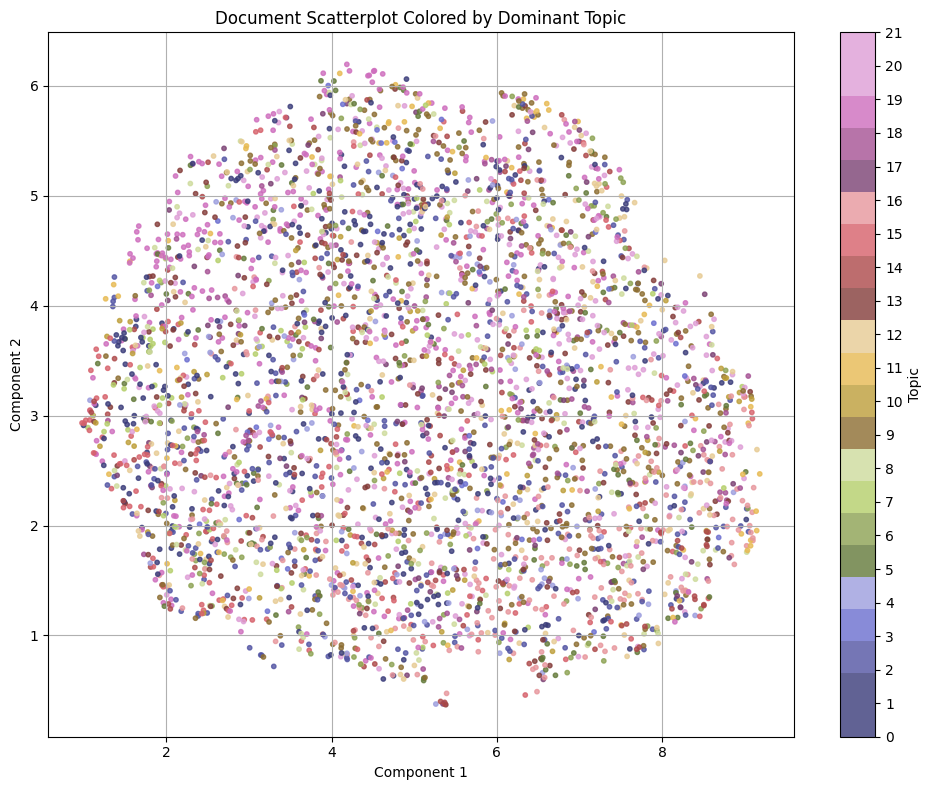

In [13]:
import matplotlib.colors as mcolors
import numpy as np

# Assume you have:
# - `embedding`: the 2D UMAP embedding (N x 2)
# - `topic_labels`: array of integers (N,) with values from 0 to 21

# 1. Generate a colormap with 22 distinct colors
cmap = plt.cm.get_cmap('tab20b', 22)  # or try 'tab20' or 'tab20c' for variation
topic_labels = topic_df['topic'].tolist()

# 2. Plot with explicit mapping
fig, ax = plt.subplots(figsize=(10, 8))
scatter = ax.scatter(
    X_umap[:, 0],
    X_umap[:, 1],
    c=topic_labels,
    cmap=cmap,
    s=10,
    alpha=0.8
)

# 3. Colorbar with correct ticks
cbar = plt.colorbar(scatter, ticks=np.arange(22))
cbar.set_label('Topic')
cbar.set_ticks(np.arange(22))
cbar.set_ticklabels([str(i) for i in range(22)])

ax.set_title("Document Scatterplot Colored by Dominant Topic")
ax.set_xlabel("Component 1")
ax.set_ylabel("Component 2")
ax.grid(True)
plt.tight_layout()
plt.show()


## <b> B - BERTEmbeddings

In [10]:
model = SentenceTransformer('all-MiniLM-L6-v2')

In [11]:
def chunk_and_embed(doc, model, max_words=100):
    words = doc.split()
    chunks = [" ".join(words[i:i+max_words]) for i in range(0, len(words), max_words)]
    chunk_embeddings = model.encode(chunks)
    return chunk_embeddings.mean(axis=0)

In [12]:
docs = topic_df['content'].tolist()

lens = [len(d.split()) for d in docs]
# document lenghts range from 50-ish words to 42k words --> embed batches and average out embeddings

In [13]:
docs = topic_df['content'].tolist()
embeddings = [chunk_and_embed(doc, model) for doc in docs]

In [27]:
n_neighbors = [5, 10, 15, 30]
min_dist = [0.01, 0.05, 0.1, 0.3]
set_op_mix_ratio = [0.2, 0.5, 0.8]

param_grid = list(itertools.product(n_neighbors, min_dist, set_op_mix_ratio))

In [39]:
param_eval = {}
for (n,d,m) in param_grid:

    X_umap = umap.UMAP(
        n_components=3,
        n_neighbors=n,
        min_dist=d,
        metric='cosine',
        set_op_mix_ratio=m,
        random_state=42
    ).fit_transform(embeddings)

    kmeans = KMeans(n_clusters=22, random_state=42)
    pred_labels = kmeans.fit_predict(X_umap)

    # Metrics
    dbi = davies_bouldin_score(X_umap, topic_labels)
    ari = adjusted_rand_score(topic_labels, pred_labels)
    nmi = normalized_mutual_info_score(topic_labels, pred_labels)

    param_eval[(n,d,m)] = {
        'dbi':dbi,
        'ari':ari,
        'nmi':nmi
    }

In [40]:
df = pd.DataFrame.from_dict(param_eval, orient='index')

In [ ]:
df

In [45]:
X_umap_3d = umap.UMAP(
    n_components=3,
    n_neighbors=30,
    min_dist=0.3,
    set_op_mix_ratio=0.5,
    metric='cosine',
    random_state=42
).fit_transform(embeddings)

In [ ]:
X_umap = umap.UMAP(
    n_neighbors=10,
    min_dist=0.1,
    set_op_mix_ratio=0.2,
    metric='cosine',
    random_state=42
).fit_transform(embeddings)

In [46]:
topic_labels = topic_df['topic'].to_numpy()

# Clustering BERT+UMAP positions
kmeans = KMeans(n_clusters=22, random_state=42)
pred_labels = kmeans.fit_predict(X_umap_3d)

# Metrics
dbi = davies_bouldin_score(X_umap_3d, topic_labels)
ari = adjusted_rand_score(topic_labels, pred_labels)
nmi = normalized_mutual_info_score(topic_labels, pred_labels)

print("Davies-Bouldin Index:", dbi)
print("ARI:", ari)
print("NMI:", nmi)

Davies-Bouldin Index: 4.672022119639774
ARI: 0.23524674939618279
NMI: 0.3919449911002956


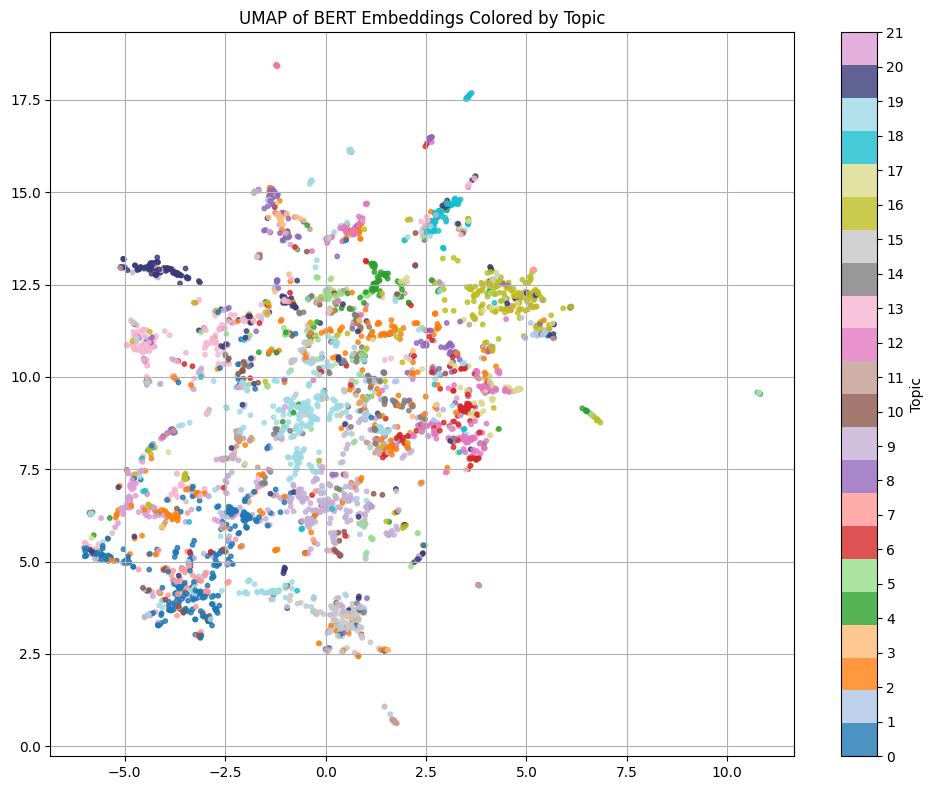

In [ ]:
from matplotlib.colors import ListedColormap
import matplotlib.pyplot as plt
import numpy as np

# Combine the base colors from multiple tab colormaps
colors = plt.cm.tab20(np.linspace(0, 1, 20)).tolist()
colors += plt.cm.tab20b(np.linspace(0, 1, 2)).tolist()  # Add 2 more unique ones

# Create a custom ListedColormap with exactly 22 distinct colors
custom_cmap = ListedColormap(colors[:22])
plt.figure(figsize=(10, 8))
scatter = plt.scatter(
    X_umap[:, 0],
    X_umap[:, 1],
    c=topic_labels,
    cmap=custom_cmap,
    s=10,
    alpha=0.8
)

cbar = plt.colorbar(scatter, ticks=np.arange(22))
cbar.set_label("Topic")
cbar.set_ticks(np.arange(22))
cbar.set_ticklabels([str(i) for i in range(22)])

plt.title("UMAP of BERT Embeddings Colored by Topic")
plt.grid(True)
plt.tight_layout()
plt.show()

In [47]:
import plotly.express as px

fig = px.scatter_3d(
    x=X_umap_3d[:, 0],
    y=X_umap_3d[:, 1],
    z=X_umap_3d[:, 2],
    color=[str(label) for label in topic_labels],
    color_discrete_sequence=px.colors.qualitative.Dark24,  # up to 24 distinct colors
    title="3D UMAP of BERT Embeddings by Topic"
)

fig.update_traces(marker=dict(size=3, opacity=0.8))
fig.show()